# Random Forest

*SPDX-FileCopyrightText: © 2026 Nina Preußler <nina.preussler@studserv.uni-leipzig.de>*

*SPDX-License-Identifier: CC BY 4.0*

In [1]:
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression

In [2]:
# import layers and combine in one dataset
ds = xr.Dataset({
    "study_area": rxr.open_rasterio('output-data/study-area/study_area.tif'),
    # predictors
    "hfp": rxr.open_rasterio('output-data/predictor-layers/hfp.tif'),
    "drainage_dist": rxr.open_rasterio("output-data/predictor-layers/drainage-dist.tif"),
    "forest_dist": rxr.open_rasterio("output-data/predictor-layers/forest-dist.tif"),
    "pre_fire_evi": rxr.open_rasterio("output-data/predictor-layers/evi_pre.tif"),
    'aridity_index': rxr.open_rasterio('output-data/predictor-layers/aridity_index.tif'),
    'fire_history': rxr.open_rasterio('output-data/predictor-layers/fire_count.tif'),
    'dnbr': rxr.open_rasterio('output-data/predictor-layers/dnbr.tif'),
    'elevation': rxr.open_rasterio('output-data/predictor-layers/elevation.tif'),
    # target variables
    'recovery_2y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2017.tif"),
    'recovery_5y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2020.tif")
    # 'recovery_2y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2017_no_neg.tif"),
    # 'recovery_5y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2020_no_neg.tif")
})

In [3]:
# transform to pandas dataframe (only study area pixels)
df = ds.to_dataframe().reset_index()

# remove pixels outside study area
df = df[df.study_area == 1]

# reset index for proper slicing later
df = df.reset_index()

# drop unnecessary columns
df = df.drop(['index', 'band', 'spatial_ref', 'study_area'], axis='columns') 

In [4]:
# check data availability
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17989 entries, 0 to 17988
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   x              17989 non-null  float64
 1   y              17989 non-null  float64
 2   hfp            17955 non-null  float32
 3   drainage_dist  17989 non-null  float64
 4   forest_dist    17989 non-null  float64
 5   pre_fire_evi   14011 non-null  float64
 6   aridity_index  17989 non-null  float64
 7   fire_history   17989 non-null  uint16 
 8   dnbr           17989 non-null  float64
 9   elevation      17989 non-null  int16  
 10  recovery_2y    14011 non-null  float64
 11  recovery_5y    14011 non-null  float64
dtypes: float32(1), float64(9), int16(1), uint16(1)
memory usage: 1.4 MB


In [5]:
# remove rows with nans
df = df.dropna()

In [6]:
# check remaining pixels
len(df) 

13981

## Data exploration

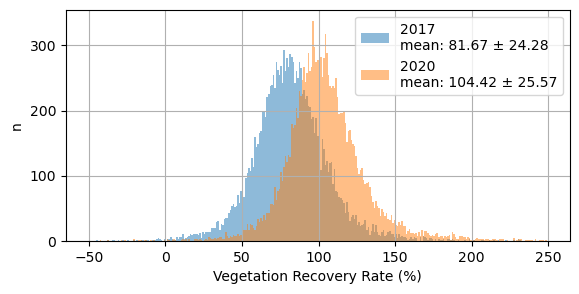

In [44]:
# histograms of predictors and target metrics

plt.subplots(figsize=(6.5,3))

# set up labels
mean_2y = df.recovery_2y.mean()
std_2y = np.std(df.recovery_2y)
label_2y = f'2017 \nmean: {mean_2y:.2f} ± {std_2y:.2f}'
mean_5y = df.recovery_5y.mean()
std_5y = np.std(df.recovery_5y)
label_5y = f'2020 \nmean: {mean_5y:.2f} ± {std_5y:.2f}'

# plot
df.recovery_2y.hist(bins=np.arange(-50,250,1), 
                    label=label_2y,
                    alpha=.5)
df.recovery_5y.hist(bins=np.arange(-50,250,1), 
                    label=label_5y,
                    alpha=.5)

# figure settings
plt.xlabel('Vegetation Recovery Rate (%)')
plt.ylabel('n')
plt.yticks(np.arange(0,350,100))
plt.legend()
# plt.grid(False)

# plt.show()
plt.savefig('figures/hist_recovery_rates.png', bbox_inches='tight', dpi=300)

## Model fitting

In [11]:
# make list with predictor column names
predictor_cols = df.columns.to_list()[2:-2]
predictor_cols

['hfp',
 'drainage_dist',
 'forest_dist',
 'pre_fire_evi',
 'aridity_index',
 'fire_history',
 'dnbr',
 'elevation']

In [12]:
# set up predictors = response
X = df[predictor_cols]
y_2y = df.recovery_2y
y_5y = df.recovery_5y

In [12]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

# takes very long (>20 min), so only do if absolutely necessary!
redo_tuning = False

if redo_tuning:
    
    param_grid = {
        "n_estimators": [200, 400, 600, 800],
        "max_features": [2, 3, 4, 5]
    }
    
    rf = RandomForestRegressor(random_state=42)
    
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
    grid = GridSearchCV(
        rf,
        param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=4
    )
    
    grid.fit(X, y_2y)
    
    print("2-year recovery")
    print(grid.best_params_)
    print(grid.best_score_)
    
    rf = RandomForestRegressor(random_state=42)
    
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
    grid = GridSearchCV(
        rf,
        param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=4
    )
    
    grid.fit(X, y_5y)
    
    print("5-year recovery")
    print(grid.best_params_)
    print(grid.best_score_)

In [13]:
# prepare 10-fold cross-validation (CV)
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict

kf = KFold(n_splits=10, 
           shuffle=True, # randomly shuffle order before making folds
           random_state=42)

In [14]:
# prepare models
from sklearn.ensemble import RandomForestRegressor

rf_2y = RandomForestRegressor(
    n_estimators=800, # number of trees 
    max_features=4, # number of features at each split
    random_state=42,
    n_jobs=4
)

rf_5y = RandomForestRegressor(
    n_estimators=800,
    max_features=4, #len(predictor_cols)-1, 
    random_state=42,
    n_jobs=4
)

In [15]:
# predict per fold (out of box)
from sklearn.metrics import r2_score, mean_squared_error


# empty lists for recording per-fold accuracy metrics
r2_2y = []
rmse_2y = []
r2_5y = []
rmse_5y = []

# add columns for prediction in dataframe
df['pred_2y'] = np.nan
df['pred_5y'] = np.nan

# loop through folds
for train_idx, test_idx in kf.split(X):

    # subset dataframe to just one fold and split train/test
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_2y, y_test_2y = y_2y.iloc[train_idx], y_2y.iloc[test_idx]
    y_train_5y, y_test_5y = y_5y.iloc[train_idx], y_5y.iloc[test_idx]

    # train on 9 training folds
    rf_2y.fit(X_train, y_train_2y)
    rf_5y.fit(X_train, y_train_5y)

    # predict for current validation fold
    pred_2y = rf_2y.predict(X_test)
    pred_5y = rf_5y.predict(X_test)

    # add prediction to dataframe
    df.iloc[test_idx, df.columns.get_loc('pred_2y')] = pred_2y
    df.iloc[test_idx, df.columns.get_loc('pred_5y')] = pred_5y

    # add metrics to list
    r2_2y.append(r2_score(y_test_2y, pred_2y))
    rmse_2y.append(np.sqrt(mean_squared_error(y_test_2y, pred_2y)))
    r2_5y.append(r2_score(y_test_5y, pred_5y))
    rmse_5y.append(np.sqrt(mean_squared_error(y_test_5y, pred_5y)))

## Model accuracy

In [16]:
# 2 year
print("2-year recovery rate prediction")
print('Mean R2:', round(np.mean(r2_2y),2))
print('SD R2:', round(np.std(r2_2y),2))

print('Mean RMSE:', round(np.mean(rmse_2y),2))
print('SD RMSE:', round(np.std(rmse_2y),2))

2-year recovery rate prediction
Mean R2: 0.56
SD R2: 0.02
Mean RMSE: 16.07
SD RMSE: 0.54


In [17]:
# 5 year
print("5-year recovery rate prediction")
print('Mean R2:', round(np.mean(r2_5y),2))
print('SD R2:', round(np.std(r2_5y),2))

print('Mean RMSE:', round(np.mean(rmse_5y),2))
print('SD RMSE:', round(np.std(rmse_5y),2))

5-year recovery rate prediction
Mean R2: 0.52
SD R2: 0.02
Mean RMSE: 17.69
SD RMSE: 0.42


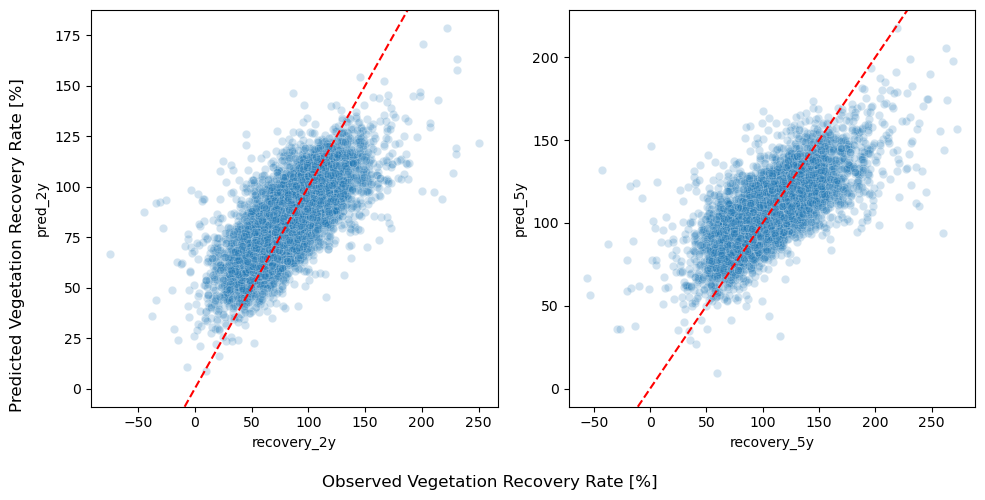

In [50]:
# scatterplot + correlation coefficient

fig, axs = plt.subplots(ncols=2, figsize=(10,5))

# 2-year
sns.scatterplot(x=df.recovery_2y, y=df.pred_2y, 
                alpha=.2, 
                ax=axs[0])
axs[0].axline(xy1=(0,0), slope=1, color='red', linestyle='--')

# 5-year
sns.scatterplot(x=df.recovery_5y, y=df.pred_5y, 
                alpha=.2,
                ax=axs[1])
axs[1].axline(xy1=(0,0), slope=1, color='red', linestyle='--')

# labels
fig.supxlabel('Observed Vegetation Recovery Rate [%]')
fig.supylabel('Predicted Vegetation Recovery Rate [%]')

plt.tight_layout()
# plt.show()
plt.savefig('figures/obs-vs-pred.png', dpi=300, bbox_inches='tight')

## Residual analysis

In [20]:
# calculate residuals
df['resid_2y'] = df.recovery_2y - df.pred_2y
df['resid_5y'] = df.recovery_5y - df.pred_5y

In [21]:
df[['resid_2y', 'resid_5y']].describe()

,resid_2y,resid_5y
count,13981.000000,13981.000000
mean,-0.009621,-0.142250
std,16.080564,17.691588
min,-141.769153,-174.616860
25%,-7.423970,-8.304460
50%,0.391286,-0.457184
75%,7.536602,7.721811
max,128.820227,166.072734


<Axes: >

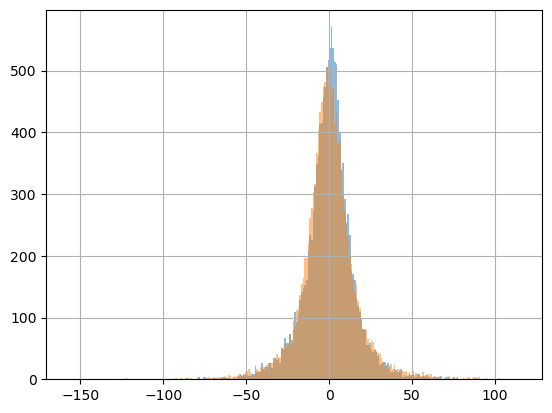

In [22]:
df.resid_2y.hist(bins=np.arange(-157, 116, 1),alpha=.5)
df.resid_5y.hist(bins=np.arange(-157, 116, 1),alpha=.5)

In [24]:
df.corr()

,x,y,hfp,drainage_dist,forest_dist,pre_fire_evi,aridity_index,fire_history,dnbr,elevation,recovery_2y,recovery_5y,pred_2y,pred_5y,resid_2y,resid_5y
x,1.000000,0.380730,0.129735,-0.022565,0.018688,0.089369,-0.590288,0.061110,0.230022,0.099387,0.078178,0.087563,0.119040,0.151208,0.001612,-0.008540
y,0.380730,1.000000,0.030397,-0.098580,-0.064000,0.185141,0.035151,-0.017919,0.080904,0.391022,0.026044,-0.003675,0.048178,-0.004786,-0.007666,-0.001031
hfp,0.129735,0.030397,1.000000,0.008132,-0.070441,0.011432,0.046285,-0.059212,-0.048233,-0.087236,0.079159,0.046399,0.124144,0.076734,-0.001843,-0.001506
drainage_dist,-0.022565,-0.098580,0.008132,1.000000,0.019521,-0.089329,0.174242,-0.113808,-0.063795,0.062906,-0.145147,-0.140765,-0.231243,-0.219498,0.006855,-0.007271
forest_dist,0.018688,-0.064000,-0.070441,0.019521,1.000000,-0.083192,-0.083465,0.642756,0.002538,0.126557,-0.045761,-0.038867,-0.072257,-0.066010,0.001539,0.002805
pre_fire_evi,0.089369,0.185141,0.011432,-0.089329,-0.083192,1.000000,-0.062935,-0.101322,0.179972,-0.160618,-0.173337,-0.102255,-0.258677,-0.150239,-0.008637,-0.013485
aridity_index,-0.590288,0.035151,0.046285,0.174242,-0.083465,-0.062935,1.000000,-0.082741,-0.235921,-0.050595,0.018156,-0.088331,0.032645,-0.139653,-0.004438,-0.002857
fire_history,0.061110,-0.017919,-0.059212,-0.113808,0.642756,-0.101322,-0.082741,1.000000,-0.010511,0.100765,0.003468,-0.062874,0.006355,-0.098320,-0.000963,-0.003000
dnbr,0.230022,0.080904,-0.048233,-0.063795,0.002538,0.179972,-0.235921,-0.010511,1.000000,0.024851,-0.054057,-0.035275,-0.083350,-0.049120,-0.000115,-0.007063
elevation,0.099387,0.391022,-0.087236,0.062906,0.126557,-0.160618,-0.050595,0.100765,0.024851,1.000000,-0.057664,-0.033762,-0.090212,-0.052683,0.001129,-0.001711


## Export

In [25]:
# rebuild grid from coordinates
ds_final = df.set_index(["y", "x"]).to_xarray()
ds_final = ds_final.rio.write_crs(ds.rio.crs)

In [26]:
# save rasters
ds_final.pred_2y.rio.to_raster('output-data/model-outcomes/pred_2yr.tif')
ds_final.pred_5y.rio.to_raster('output-data/model-outcomes/pred_5y.tif')
ds_final.resid_2y.rio.to_raster('output-data/model-outcomes/resid_2y.tif')
ds_final.resid_5y.rio.to_raster('output-data/model-outcomes/resid_5y.tif')

## Variable importance

In [23]:
# train models on full data (for next steps)
rf_2y.fit(X, y_2y)
rf_5y.fit(X, y_5y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",800
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [24]:
# 2 years
importances = rf_2y.feature_importances_

importance_df = pd.DataFrame({
    "variable": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df

,variable,importance
4,aridity_index,0.190561
1,drainage_dist,0.170518
3,pre_fire_evi,0.151193
0,hfp,0.145459
6,dnbr,0.128210
2,forest_dist,0.096155
7,elevation,0.072661
5,fire_history,0.045242


In [25]:
# 5 years
importances = rf_5y.feature_importances_

importance_df = pd.DataFrame({
    "variable": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df

,variable,importance
4,aridity_index,0.192199
3,pre_fire_evi,0.153680
1,drainage_dist,0.144589
0,hfp,0.142691
6,dnbr,0.134877
2,forest_dist,0.111641
7,elevation,0.071167
5,fire_history,0.049156


## Variable effects (partial dependence)

In [26]:
from sklearn.inspection import PartialDependenceDisplay

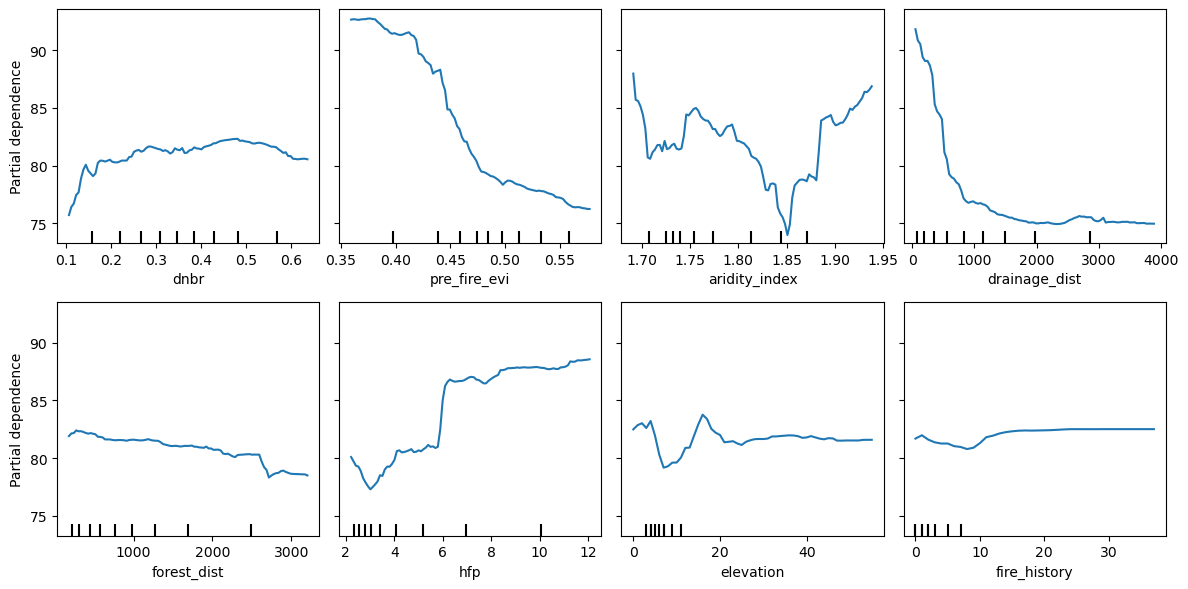

In [62]:
# 2 years

fig, axs = plt.subplots(2, 4, figsize=(12, 6))  # adjust as needed

PartialDependenceDisplay.from_estimator(
    rf_2y,
    X.astype(float),
    ['dnbr', 'pre_fire_evi', 'aridity_index', 'drainage_dist', 'forest_dist', 'hfp', 'elevation', 'fire_history'],
    ax=axs
)

plt.tight_layout()
# plt.show()
plt.savefig('figures/pdp_2y.png', dpi=300, bbox_inches='tight')

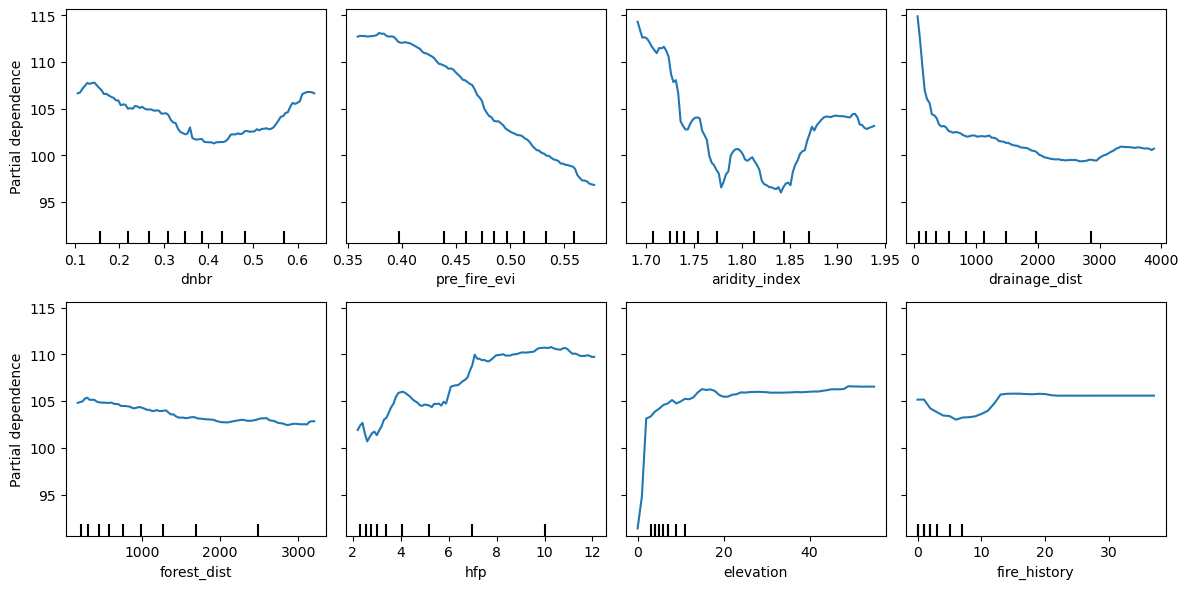

In [64]:
# 5 years

fig, axs = plt.subplots(2, 4, figsize=(12, 6))  # adjust as needed

PartialDependenceDisplay.from_estimator(
    rf_5y,
    X.astype(float),
    ['dnbr', 'pre_fire_evi', 'aridity_index', 'drainage_dist', 'forest_dist', 'hfp', 'elevation', 'fire_history'],
    ax=axs
)

plt.tight_layout()
# plt.show()
plt.savefig('figures/pdp_5y.png', dpi=300, bbox_inches='tight')